# 02 — JSON

Same fetch, different shape. Where notebook 01 got a flat table of text, this one
gets **nested** text: objects `{}` and lists `[]`.

JSON is what most modern APIs answer in, so this is the one you will meet most.

## 1. What we're fetching

```bash
https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?product=wind&application=beginners&begin_date=20240115&end_date=20240116&station=9414290&time_zone=gmt&units=metric&interval=h&format=json
```

NOAA's tides and currents service, wind observations from a station near San
Francisco. No key, no account, no rate limit to worry about.

Three useful things about how this URL is written, because they are true of most
real APIs:

  * parameters are `name=value`, joined by `&`
  * `application=something` is a courtesy — most APIs ask you to identify yourself
  * `format=json` is the default here, but on many APIs `format=csv` or
    `format=json` is how you choose the shape. **The same service, three shapes.**

In [1]:
import matplotlib.pyplot as plt
import requests

COOPS_URL = (
    "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
    "?product=wind&application=beginners"
    "&begin_date=20240115&end_date=20240116&station=9414290"
    "&time_zone=gmt&units=metric&interval=h&format=json"
)

r = requests.get(COOPS_URL, timeout=30)
r.raise_for_status()
print(r.status_code, len(r.content), "bytes")
print()
print(r.text[:300])

200 3997 bytes

{"metadata":{"id":"9414290","name":"San Francisco","lat":"37.8063","lon":"-122.4659"}, "data": [{"t":"2024-01-15 00:00", "s":"2.7", "d":"251.0", "dr":"WSW", "g":"4.0", "f":"0,0"},{"t":"2024-01-15 01:00", "s":"2.6", "d":"231.0", "dr":"SW", "g":"3.6", "f":"0,0"},{"t":"2024-01-15 02:00", "s":"0.6", "d"


## 2. `r.json()` — one line, and it is the whole difference

`r.text` would give you the string. `r.json()` gives you **Python objects**: dicts for
`{}`, lists for `[]`, numbers, strings, `True`/`False`, `None`.

Look at the shape before you do anything else. Printing the type and the keys is the
first move in any JSON work.

In [2]:
payload = r.json()

print("type:", type(payload).__name__)
print("top-level keys:", list(payload.keys()))
print()
print("metadata:", payload["metadata"])
print()
print("type of ['data']:", type(payload["data"]).__name__, "with", len(payload["data"]), "items")
print("first item:", payload["data"][0])

type: dict
top-level keys: ['metadata', 'data']

metadata: {'id': '9414290', 'name': 'San Francisco', 'lat': '37.8063', 'lon': '-122.4659'}

type of ['data']: list with 48 items
first item: {'t': '2024-01-15 00:00', 's': '2.7', 'd': '251.0', 'dr': 'WSW', 'g': '4.0', 'f': '0,0'}


## 3. The shape, drawn out

```
{                              <- one object
  "metadata": { ... },         <- an object inside it
  "data": [                    <- a list inside it
    { "t": "...", "s": ... }, <- objects inside the list
    { "t": "...", "s": ... },
    ...
  ]
}
```

A **list of objects** is the shape you want, because it is exactly a table. Dig to it
and hand it to pandas.

In [3]:
import pandas as pd

df = pd.json_normalize(payload["data"])
print(df.shape, list(df.columns))
print(df.head(3).to_string(index=False))

(48, 6) ['t', 's', 'd', 'dr', 'g', 'f']
               t   s     d  dr   g   f
2024-01-15 00:00 2.7 251.0 WSW 4.0 0,0
2024-01-15 01:00 2.6 231.0  SW 3.6 0,0
2024-01-15 02:00 0.6 140.0  SE 1.3 0,0


`pd.json_normalize` takes a list of dicts and gives you one column per key, nesting
included. `pd.DataFrame(payload["data"])` does the same when there is no nesting to
flatten. Start with `json_normalize` — it is never worse.

## 4. Now the annoying part, and it is not the parsing

Those column names are `t`, `s`, `d`, `dr`, `g`, `f`. Single letters.

In [4]:
print(df.head(2).to_string(index=False))
print()
print("Six columns. Six single letters. Nothing is wrong with the data; the server")
print("simply refuses to be helpful. You have to know that")
print("  t  = time")
print("  s  = speed, m/s")
print("  d  = direction, degrees true")
print("  dr = direction, as text (WSW)")
print("  g  = gust, m/s")
print("  f  = flags")
print()
print("and that information is in the product documentation, not in the response.")

               t   s     d  dr   g   f
2024-01-15 00:00 2.7 251.0 WSW 4.0 0,0
2024-01-15 01:00 2.6 231.0  SW 3.6 0,0

Six columns. Six single letters. Nothing is wrong with the data; the server
simply refuses to be helpful. You have to know that
  t  = time
  s  = speed, m/s
  d  = direction, degrees true
  dr = direction, as text (WSW)
  g  = gust, m/s
  f  = flags

and that information is in the product documentation, not in the response.


**This is the real lesson of JSON, and it is not about syntax.** Any API will hand you
data in a shape chosen by whoever built the service, with names chosen for their
database, not for you. There is no technique that avoids reading the documentation.
The best you can do is *look at the names before you trust them* — and `df.columns`
costs nothing.

Renaming is trivial once you know:

In [5]:
wind = df.rename(columns={
    "t": "time", "s": "speed_ms", "d": "direction_deg",
    "dr": "direction_text", "g": "gust_ms", "f": "flags",
})
wind["time"] = pd.to_datetime(wind["time"])
wind = wind.sort_values("time")

print(wind.head(3).to_string(index=False))
print()
print("Names you chose, rather than names you inherited.")

               time speed_ms direction_deg direction_text gust_ms flags
2024-01-15 00:00:00      2.7         251.0            WSW     4.0   0,0
2024-01-15 01:00:00      2.6         231.0             SW     3.6   0,0
2024-01-15 02:00:00      0.6         140.0             SE     1.3   0,0

Names you chose, rather than names you inherited.


## 5. DuckDB on JSON

Worth knowing where DuckDB stops helping. It reads **list-shaped** JSON in one line,
but this response is an *object* wrapping the list, so DuckDB sees one row with two
nested columns. You would reach for the JSON pointer syntax, and at this point you are
happier in pandas.

In [6]:
import duckdb

# A list-shaped JSON response: DuckDB, one line.
listy = duckdb.sql("""
    SELECT * FROM read_json_auto(
        'https://api.open-meteo.com/v1/forecast'
        '?latitude=36.7&longitude=-122.1&current=temperature_2m&timezone=UTC'
    )
""").df()
print("open-meteo (object-wrapped too):", listy.shape, listy.columns) if False else None

# The honest demonstration: our object-shaped response comes back as ONE row.
one = duckdb.sql(f"SELECT * FROM read_json_auto('{COOPS_URL}')").df()
print("CO-OPS via DuckDB ->", one.shape, "row")
print("  columns:", list(one.columns))
print()
print("  DuckDB parsed the object correctly; it just treats an object as a single")
print("  record, so the 48 measurements are a nested list inside one cell.")
print("  For list-shaped JSON it is genuinely one line -- see the docs for read_json.")

CO-OPS via DuckDB -> (1, 2) row
  columns: ['metadata', 'data']

  DuckDB parsed the object correctly; it just treats an object as a single
  record, so the 48 measurements are a nested list inside one cell.
  For list-shaped JSON it is genuinely one line -- see the docs for read_json.


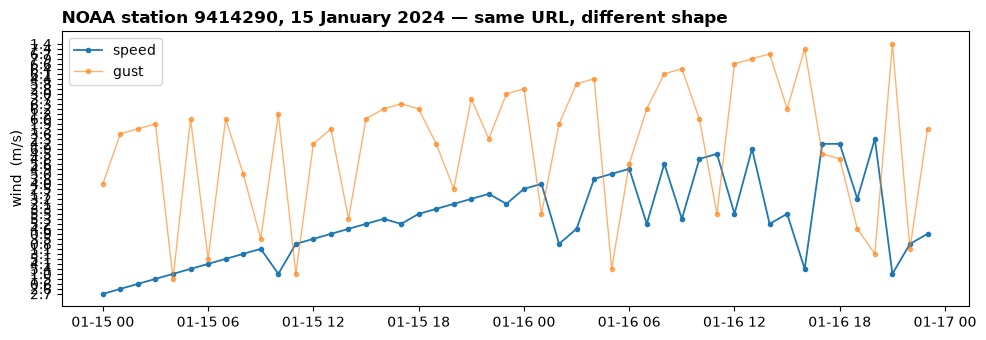

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(wind.time, wind.speed_ms, marker="o", ms=3, lw=1.3, label="speed")
ax.plot(wind.time, wind.gust_ms, marker="o", ms=3, lw=1.0, alpha=0.6, label="gust")
ax.set_ylabel("wind  (m/s)")
ax.set_xlabel("")
ax.legend()
ax.set_title("NOAA station 9414290, 15 January 2024 — same URL, different shape",
             loc="left", fontweight="bold")
plt.tight_layout()
plt.show()